In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from matplotlib.patches import Patch
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('titanic_cleaned.csv')
df.head()

,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


### Section 1 — Univariate Analysis (Single Column)

Passengers survived vs did not survive
Survived: 320
Not survive: 455
Survival Rate: 41.29%



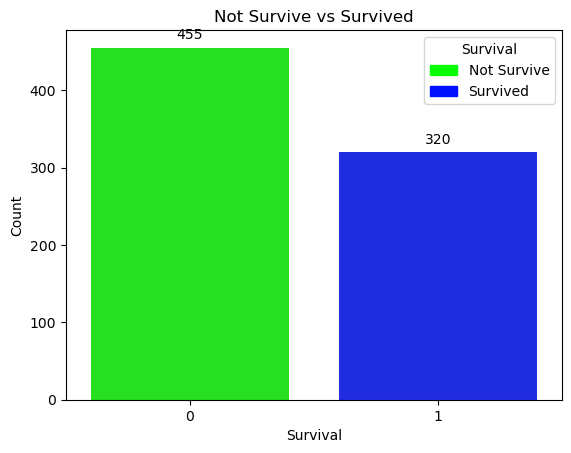

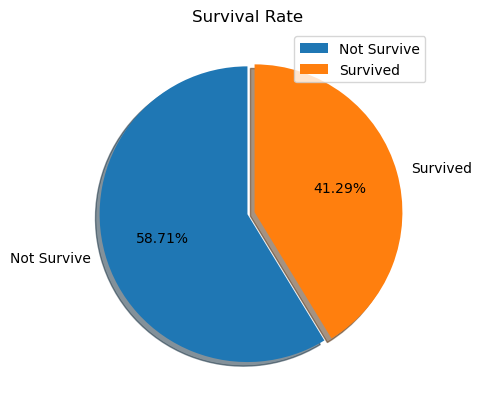

In [3]:
# How many passengers survived vs did not survive? 
survive = df['survived'].value_counts()
print("Passengers survived vs did not survive")
print(f"Survived: {survive[1]}")
print(f"Not survive: {survive[0]}")

survival_rate = (survive[1] / len(df) * 100).round(2)
print(f"Survival Rate: {survival_rate}%")
print()

ax = sns.barplot(x=survive.index, y=survive.values, palette='hsv')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)

legend_labels = ["Not Survive", "Survived"]
legend_colors = sns.color_palette('hsv', n_colors=2)
handles = [Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(2)]
plt.legend(handles=handles, title="Survival")

plt.xlabel("Survival")
plt.ylabel("Count")
plt.title("Not Survive vs Survived")
plt.show()


values = [100 - survival_rate, survival_rate]
plt.pie(values, labels= legend_labels, autopct='%1.2f%%', explode=[0,0.05],shadow=True, startangle=90)
plt.title("Survival Rate")
plt.legend()
plt.show()

Passengers Distribution
pclass
3    401
1    210
2    164
Name: count, dtype: int64
Class 3 has 401 passengers (most among all)


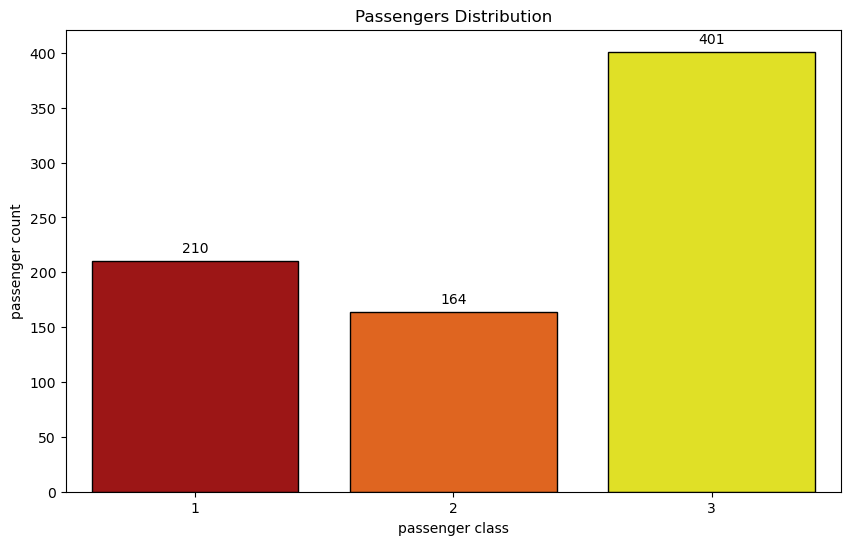

In [4]:
# What is the distribution of passenger classes (pclass)? Which class had the most passengers?
psng_dist = df['pclass'].value_counts()
print("Passengers Distribution")
print(psng_dist)

print(f"Class {psng_dist.index[0]} has {psng_dist.iloc[0]} passengers (most among all)")

plt.figure(figsize=(10,6))
ax = sns.barplot(x=psng_dist.index, y=psng_dist.values, palette='hot', edgecolor='black')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)

plt.title("Passengers Distribution")
plt.xlabel("passenger class")
plt.ylabel("passenger count")
plt.show()



The most common age group in titanic is 28.0


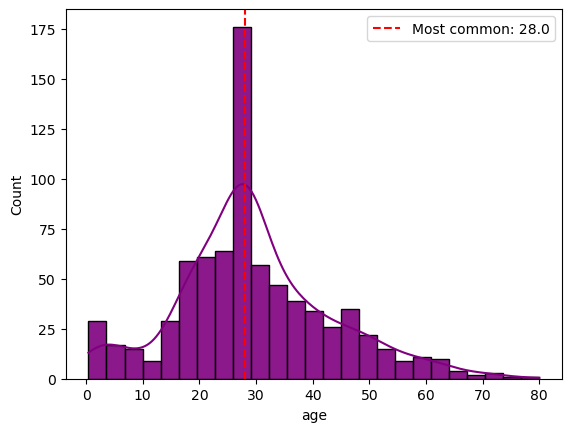

In [5]:
# Plot the distribution of age using a histogram. What is the most common age group on the Titanic?

sns.histplot(data=df, x='age', bins=25, color='purple', kde=True, alpha=0.9)
common_group = df['age'].mode()[0]
print(f"The most common age group in titanic is {common_group}")

plt.axvline(common_group, color='red', linestyle='--', label=f"Most common: {common_group}")
plt.legend()
plt.show()

Stastical Summary of fare
count    775.000000
mean      34.878403
std       52.408474
min        0.000000
25%        8.050000
50%       15.900000
75%       34.197900
max      512.329200
Name: fare, dtype: float64



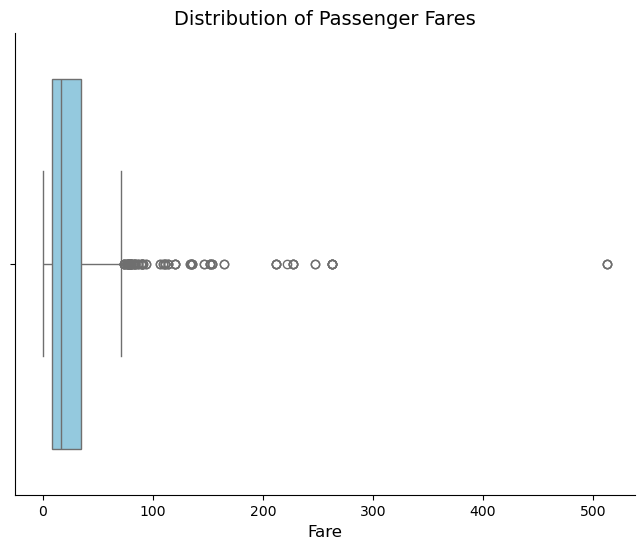

In [6]:
# Analyze the fare column — what is the min, max, mean, and median fare? Are there any extreme outliers?
print("Stastical Summary of fare")
print(df['fare'].describe())
print()

plt.figure(figsize=(8,6))
ax = sns.boxplot(data=df, x='fare', color='skyblue')

ax.set_title("Distribution of Passenger Fares", fontsize=14)
ax.set_xlabel("Fare", fontsize=12)

sns.despine()

plt.show()


#### Section 2 — Bivariate Analysis (Two Columns)

Survival Rate By Sex
==== Male ====
Male Survived: 104
Male Survival Rate: 21.53%
==== Female ====
Female Survived: 216
Female Survival Rate: 73.97%
Female have a 52.44% higher chance of survival


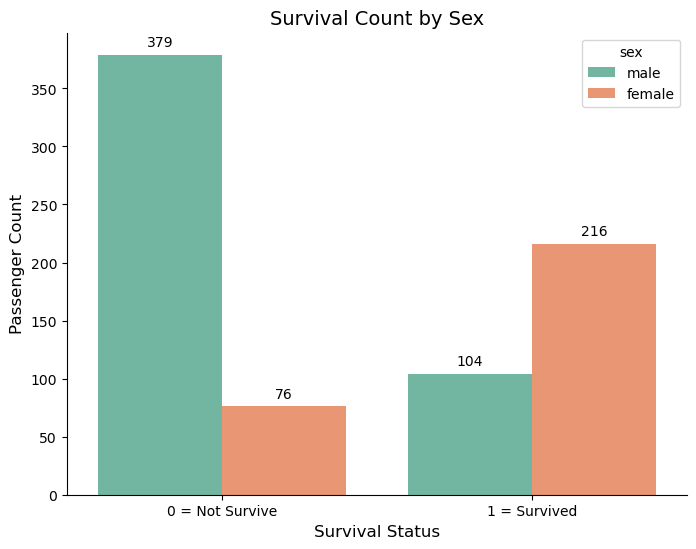

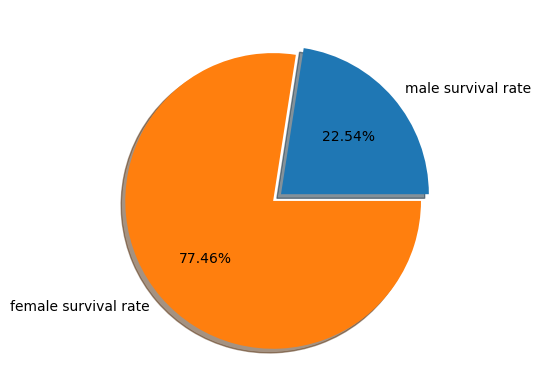

In [38]:
# What is the survival rate by sex? Did males or females have a higher chance of survival?
survive_sex = df.groupby('sex')['survived'].value_counts()

male_sur = survive_sex.loc[('male', 1)]
male_total = survive_sex.loc['male'].sum()
male_surv_rate = (male_sur / male_total * 100).round(2)

female_sur = survive_sex.loc[('female', 1)]
female_total = survive_sex.loc['female'].sum()
female_surv_rate = (female_sur / female_total * 100).round(2)

print("Survival Rate By Sex")
print("==== Male ====")
print(f"Male Survived: {male_sur}")
print(f"Male Survival Rate: {male_surv_rate}%")
print("==============")

print("==== Female ====")
print(f"Female Survived: {female_sur}")
print(f"Female Survival Rate: {female_surv_rate}%")
print("================")

diff = abs(male_surv_rate - female_surv_rate)

if male_surv_rate > female_surv_rate: 
    print(f"Male have a {diff:.2f}% higher chance of survival")
else:
    print(f"Female have a {diff:.2f}% higher chance of survival")

plt.figure(figsize=(8,6))
ax = sns.countplot(data=df, x='survived', hue='sex', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(["0 = Not Survive", "1 = Survived"])

ax.set_title("Survival Count by Sex", fontsize=14)
ax.set_xlabel("Survival Status", fontsize=12)
ax.set_ylabel("Passenger Count", fontsize=12)

sns.despine()
plt.show()

plt.pie([male_surv_rate, female_surv_rate], labels=['male survival rate', 'female survival rate'],
        autopct='%1.2f%%', explode=[0,0.07], shadow=True
       )
plt.show()

survival rate across passenger classes (pclass)

======= pclass - 1 =======
pclass-1 Survived: 133
pclass-1 Survival rate: 63.33%

======= pclass - 2 =======
pclass-2 Survived: 83
pclass-2 Survival rate: 50.61%

======= pclass - 3 =======
pclass-3 Survived: 104
pclass-3 Survival rate: 25.94%

Class 1 has the best survival rate: 63.33%


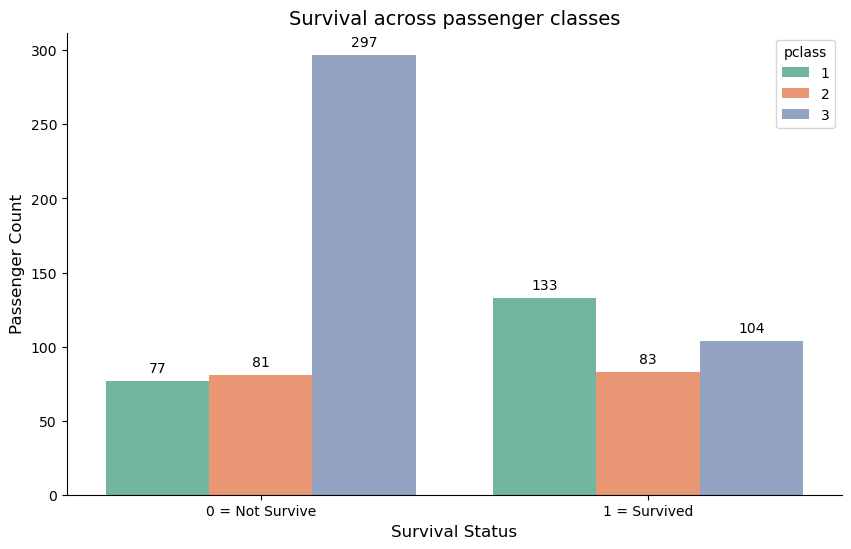

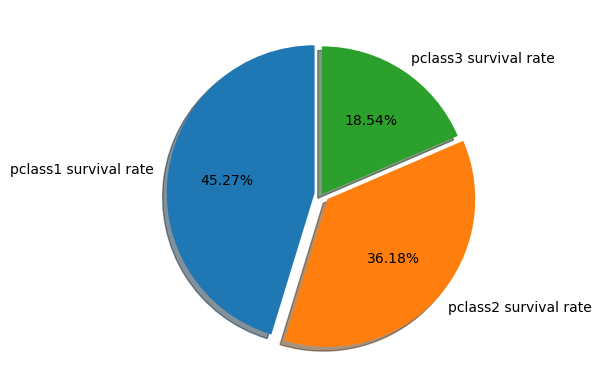

In [35]:
# Compare survival rate across passenger classes (pclass). Which class had the best survival rate?
psg_sur = df.groupby('pclass')['survived'].value_counts()

c1_surv = psg_sur.loc[(1,1)]
c1_total = psg_sur.loc[1].sum()
c1_sur_rate = (c1_surv / c1_total * 100).round(2)

c2_surv = psg_sur.loc[(2,1)]
c2_total = psg_sur.loc[2].sum()
c2_sur_rate = (c2_surv / c2_total * 100).round(2)

c3_surv = psg_sur.loc[(3,1)]
c3_total = psg_sur.loc[3].sum()
c3_sur_rate = (c3_surv / c3_total * 100).round(2)

print("survival rate across passenger classes (pclass)")
print("\n======= pclass - 1 =======")
print(f"pclass-1 Survived: {c1_surv}")
print(f"pclass-1 Survival rate: {c1_sur_rate}%")
print("==========================\n")

print("======= pclass - 2 =======")
print(f"pclass-2 Survived: {c2_surv}")
print(f"pclass-2 Survival rate: {c2_sur_rate}%")
print("==========================\n")

print("======= pclass - 3 =======")
print(f"pclass-3 Survived: {c3_surv}")
print(f"pclass-3 Survival rate: {c3_sur_rate}%")
print("==========================\n")

rates = {'Class 1': c1_sur_rate, 'Class 2': c2_sur_rate, 'Class 3': c3_sur_rate}
best = max(rates, key=rates.get)
print(f"{best} has the best survival rate: {rates[best]}%")


plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='survived', hue='pclass', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(["0 = Not Survive", "1 = Survived"])

ax.set_title("Survival across passenger classes", fontsize=14)
ax.set_xlabel("Survival Status", fontsize=12)
ax.set_ylabel("Passenger Count", fontsize=12)

sns.despine()
plt.show()

plt.pie([c1_sur_rate, c2_sur_rate, c3_sur_rate], labels=['pclass1 survival rate', 'pclass2 survival rate', 'pclass3 survival rate'],
        autopct='%1.2f%%', explode=[0.05,0.05,0], shadow=True, startangle=90
       )
plt.show()

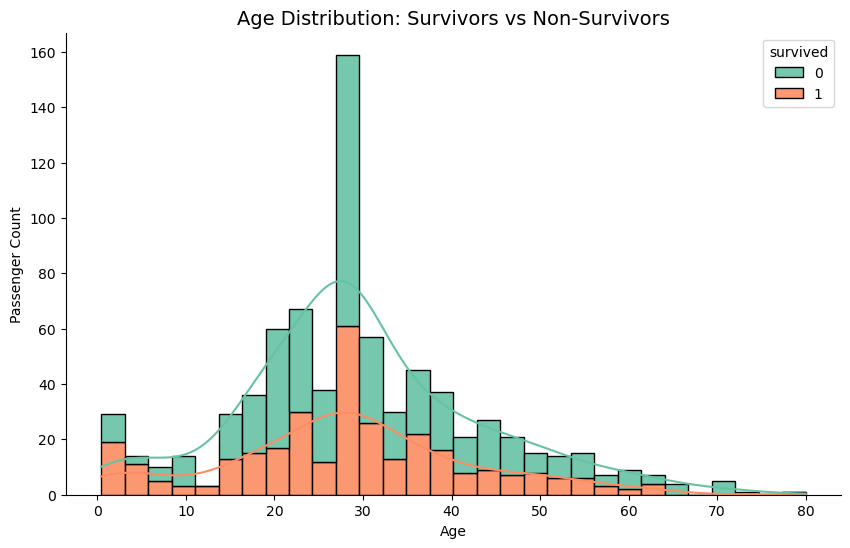

Median age - Survived: 28.0, Not Survived: 28.0


In [36]:
# Is there a relationship between age and survival? Plot age distributions for survivors vs non-survivors. 
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='survived', bins=30, multiple='stack', palette='Set2', kde=True, alpha=0.9)

plt.title("Age Distribution: Survivors vs Non-Survivors", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Passenger Count")
sns.despine()
plt.show()


survived_median = df[df['survived'] == 1]['age'].median()
not_survived_median = df[df['survived'] == 0]['age'].median()
print(f"Median age - Survived: {survived_median}, Not Survived: {not_survived_median}")

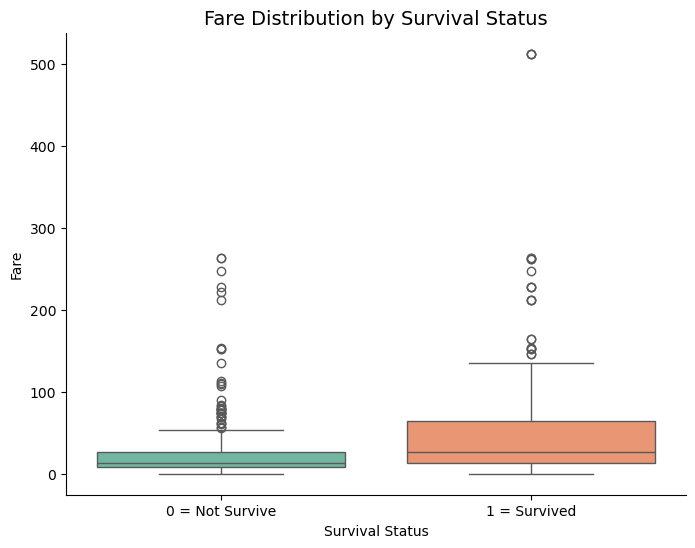

In [10]:
# Did passengers who paid a higher fare have better survival chances? Use a boxplot to compare fare by survival.
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='survived', y='fare', palette='Set2')

plt.xticks([0,1], ["0 = Not Survive", "1 = Survived"])
plt.title("Fare Distribution by Survival Status", fontsize=14)
plt.xlabel("Survival Status")
plt.ylabel("Fare")
sns.despine()
plt.show()

survival rate by embark_town (Boarding Location)

======= Cherbourg =======
Cherbourg Survived: 90
Cherbourg Survival rate: 58.06%

======= Queenstown =======
Queenstown Survived: 20
Queenstown Survival rate: 34.48%

======= Southampton =======
Southampton Survived: 210
Southampton Survival rate: 37.37%

Cherbourg passengers has the best survival rate: 58.06%


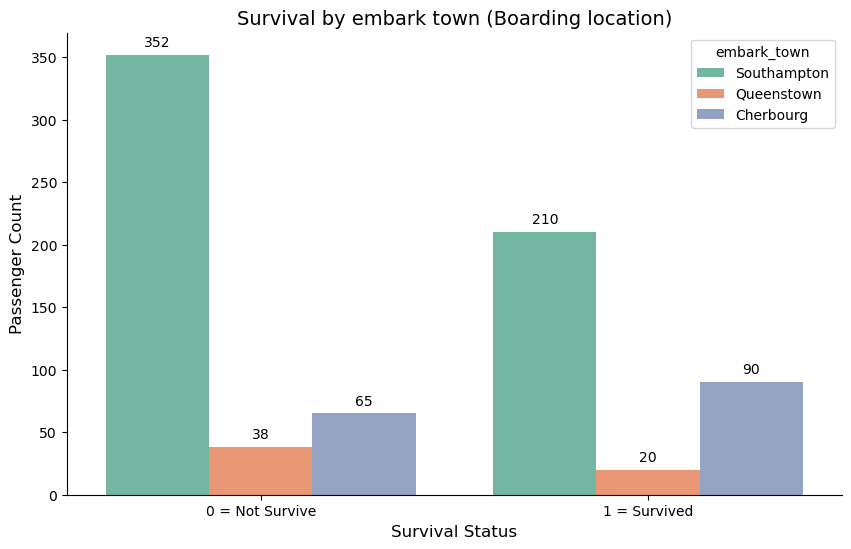

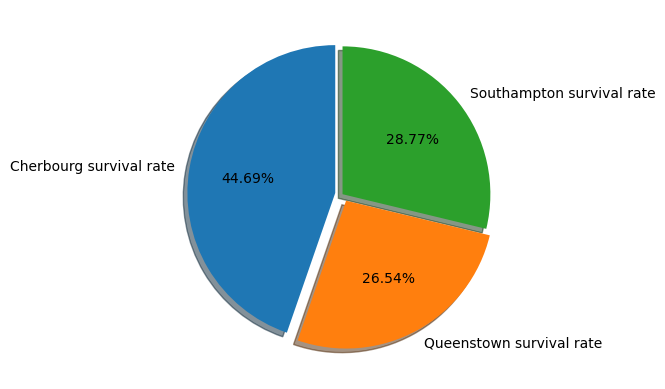

In [40]:
# Analyze survival rate by embark_town. Did the boarding location affect survival?
embark_town_sur = df.groupby('embark_town')['survived'].value_counts()

C_surv = embark_town_sur.loc[('Cherbourg',1)]
C_total = embark_town_sur.loc['Cherbourg'].sum()
C_sur_rate = (C_surv / C_total * 100).round(2)

Q_surv = embark_town_sur.loc[('Queenstown',1)]
Q_total = embark_town_sur.loc['Queenstown'].sum()
Q_sur_rate = (Q_surv / Q_total * 100).round(2)

S_surv = embark_town_sur.loc[('Southampton',1)]
S_total = embark_town_sur.loc['Southampton'].sum()
S_sur_rate = (S_surv / S_total * 100).round(2)


print("survival rate by embark_town (Boarding Location)")
print("\n======= Cherbourg =======")
print(f"Cherbourg Survived: {C_surv}")
print(f"Cherbourg Survival rate: {C_sur_rate}%")
print("===========================\n")

print("======= Queenstown =======")
print(f"Queenstown Survived: {Q_surv}")
print(f"Queenstown Survival rate: {Q_sur_rate}%")
print("===========================\n")

print("======= Southampton =======")
print(f"Southampton Survived: {S_surv}")
print(f"Southampton Survival rate: {S_sur_rate}%")
print("===========================\n")


town_rates = {'Cherbourg': C_sur_rate, 'Queenstown': Q_sur_rate, 'Southampton': S_sur_rate}
best = max(town_rates, key=town_rates.get)
print(f"{best} passengers has the best survival rate: {town_rates[best]}%")


plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='survived', hue='embark_town', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(["0 = Not Survive", "1 = Survived"])

ax.set_title("Survival by embark town (Boarding location)", fontsize=14)
ax.set_xlabel("Survival Status", fontsize=12)
ax.set_ylabel("Passenger Count", fontsize=12)

sns.despine()
plt.show()

plt.pie([C_sur_rate, Q_sur_rate, S_sur_rate], labels=['Cherbourg survival rate', 'Queenstown survival rate', 'Southampton survival rate'],
        autopct='%1.2f%%', explode=[0.05,0.05,0], shadow=True, startangle=90
       )
plt.show()

### Section 3 — Multivariate Analysis (3+ Columns)

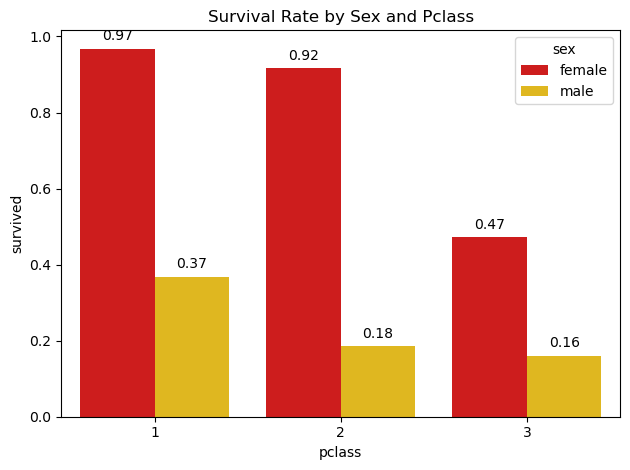

In [12]:
# Plot survival rate by both sex and pclass together using a grouped bar chart.
grouped = df.groupby(['sex','pclass'])['survived'].mean().reset_index()

ax = sns.barplot(
    x='pclass', 
    y='survived', 
    hue='sex', 
    data=grouped, 
    palette='hot'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4)

ax.set_title("Survival Rate by Sex and Pclass")
plt.tight_layout()
plt.show()

In [13]:
# Create a pivot table showing average survival rate grouped by pclass and sex.
pivot = pd.pivot_table(
    data=df,
    values='survived', 
    index='pclass', 
    columns='sex', 
    aggfunc='mean'
)

print("Average survival rate grouped by pclass and sex")
pivot

Average survival rate grouped by pclass and sex


sex,female,male
pclass,,
1,0.967742,0.367521
2,0.916667,0.184783
3,0.472441,0.160584


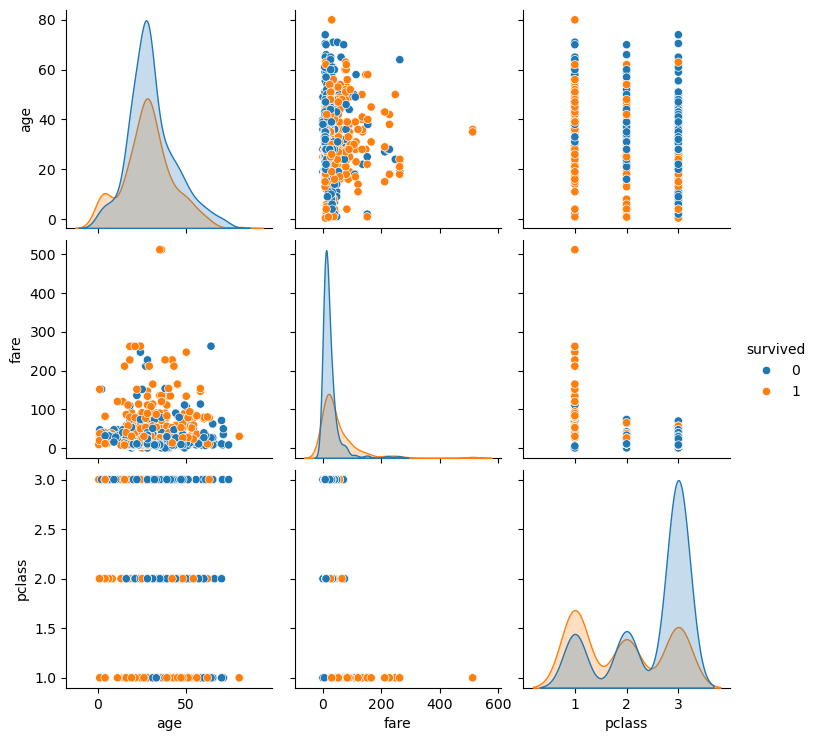

In [14]:
# How does age, fare, and pclass relate to each other? Use a pairplot to visualize.
sns.pairplot(df, vars=['age', 'fare', 'pclass'], hue='survived')
plt.show()

### Section 4 — Correlation Analysis

In [15]:
# Compute the correlation matrix of all numerical columns. Which features are most correlated with survival? 
df['sex_encoded'] = df['sex'].map({'male':0, 'female':1})
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix['survived'].sort_values(ascending=False))


survived            1.000000
sex_encoded         0.516121
fare                0.247159
parents_children    0.069864
siblings_spouses   -0.037841
age                -0.078114
alone              -0.176714
pclass             -0.331388
adult_male         -0.529158
Name: survived, dtype: float64


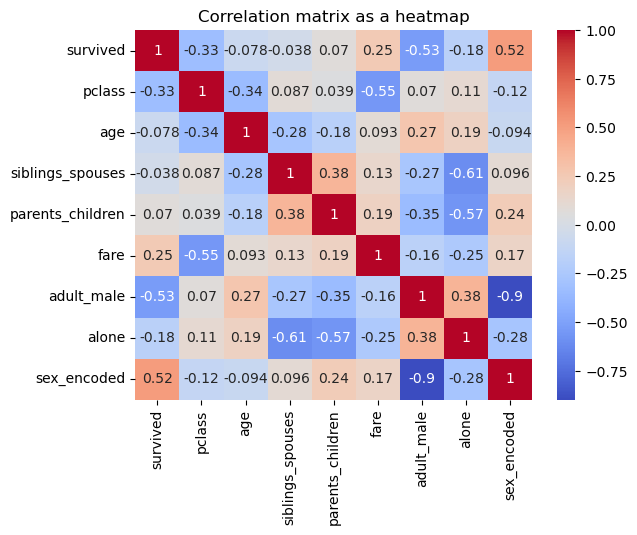

In [34]:
# Visualize the correlation matrix as a heatmap with annotations. Which two columns have the strongest relationship?
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation matrix as a heatmap")
plt.show()

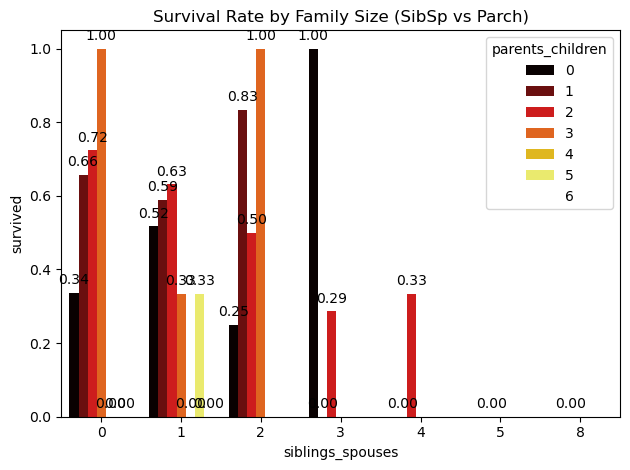

Small families (1-2 members) had better survival rates than solo travelers or large families


In [37]:
# Is there a correlation between siblings_spouses / parents_children and survival? What does this tell us?
grp = df.groupby(['siblings_spouses', 'parents_children'])['survived'].mean().reset_index()

ax = sns.barplot(
    x='siblings_spouses', 
    y='survived', 
    hue='parents_children', 
    data=grp, 
    palette='hot'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4)

ax.set_title("Survival Rate by Family Size (SibSp vs Parch)")
plt.tight_layout()
plt.show()


print("Small families (1-2 members) had better survival rates than solo travelers or large families")

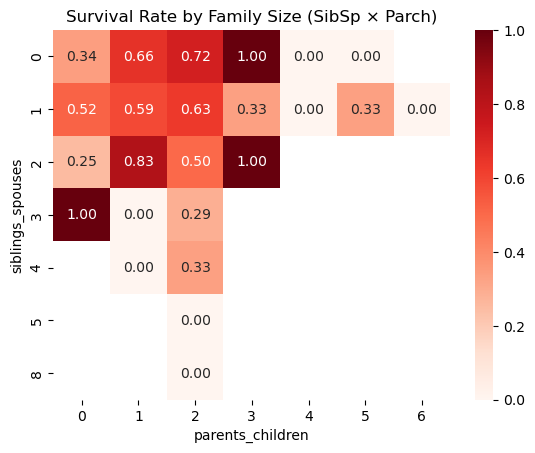

In [32]:
# Survival rate in matrix
heatmap_data = df.groupby(['siblings_spouses','parents_children'])['survived'].mean().unstack()

sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds")
plt.title("Survival Rate by Family Size (SibSp × Parch)")
plt.show()

### Section 5 — Insights & Observations

## Key Insights 
- Class 3 has 401 passengers (most among all)
- The most common age group in titanic is 28 years
- Female have a 52.44% higher chance of survival
- Class 1 has the best survival rate: 63.33%
- Cherbourg passengers has the best survival rate: 58.06%
- Passengers who paid higher fares had better survival chances

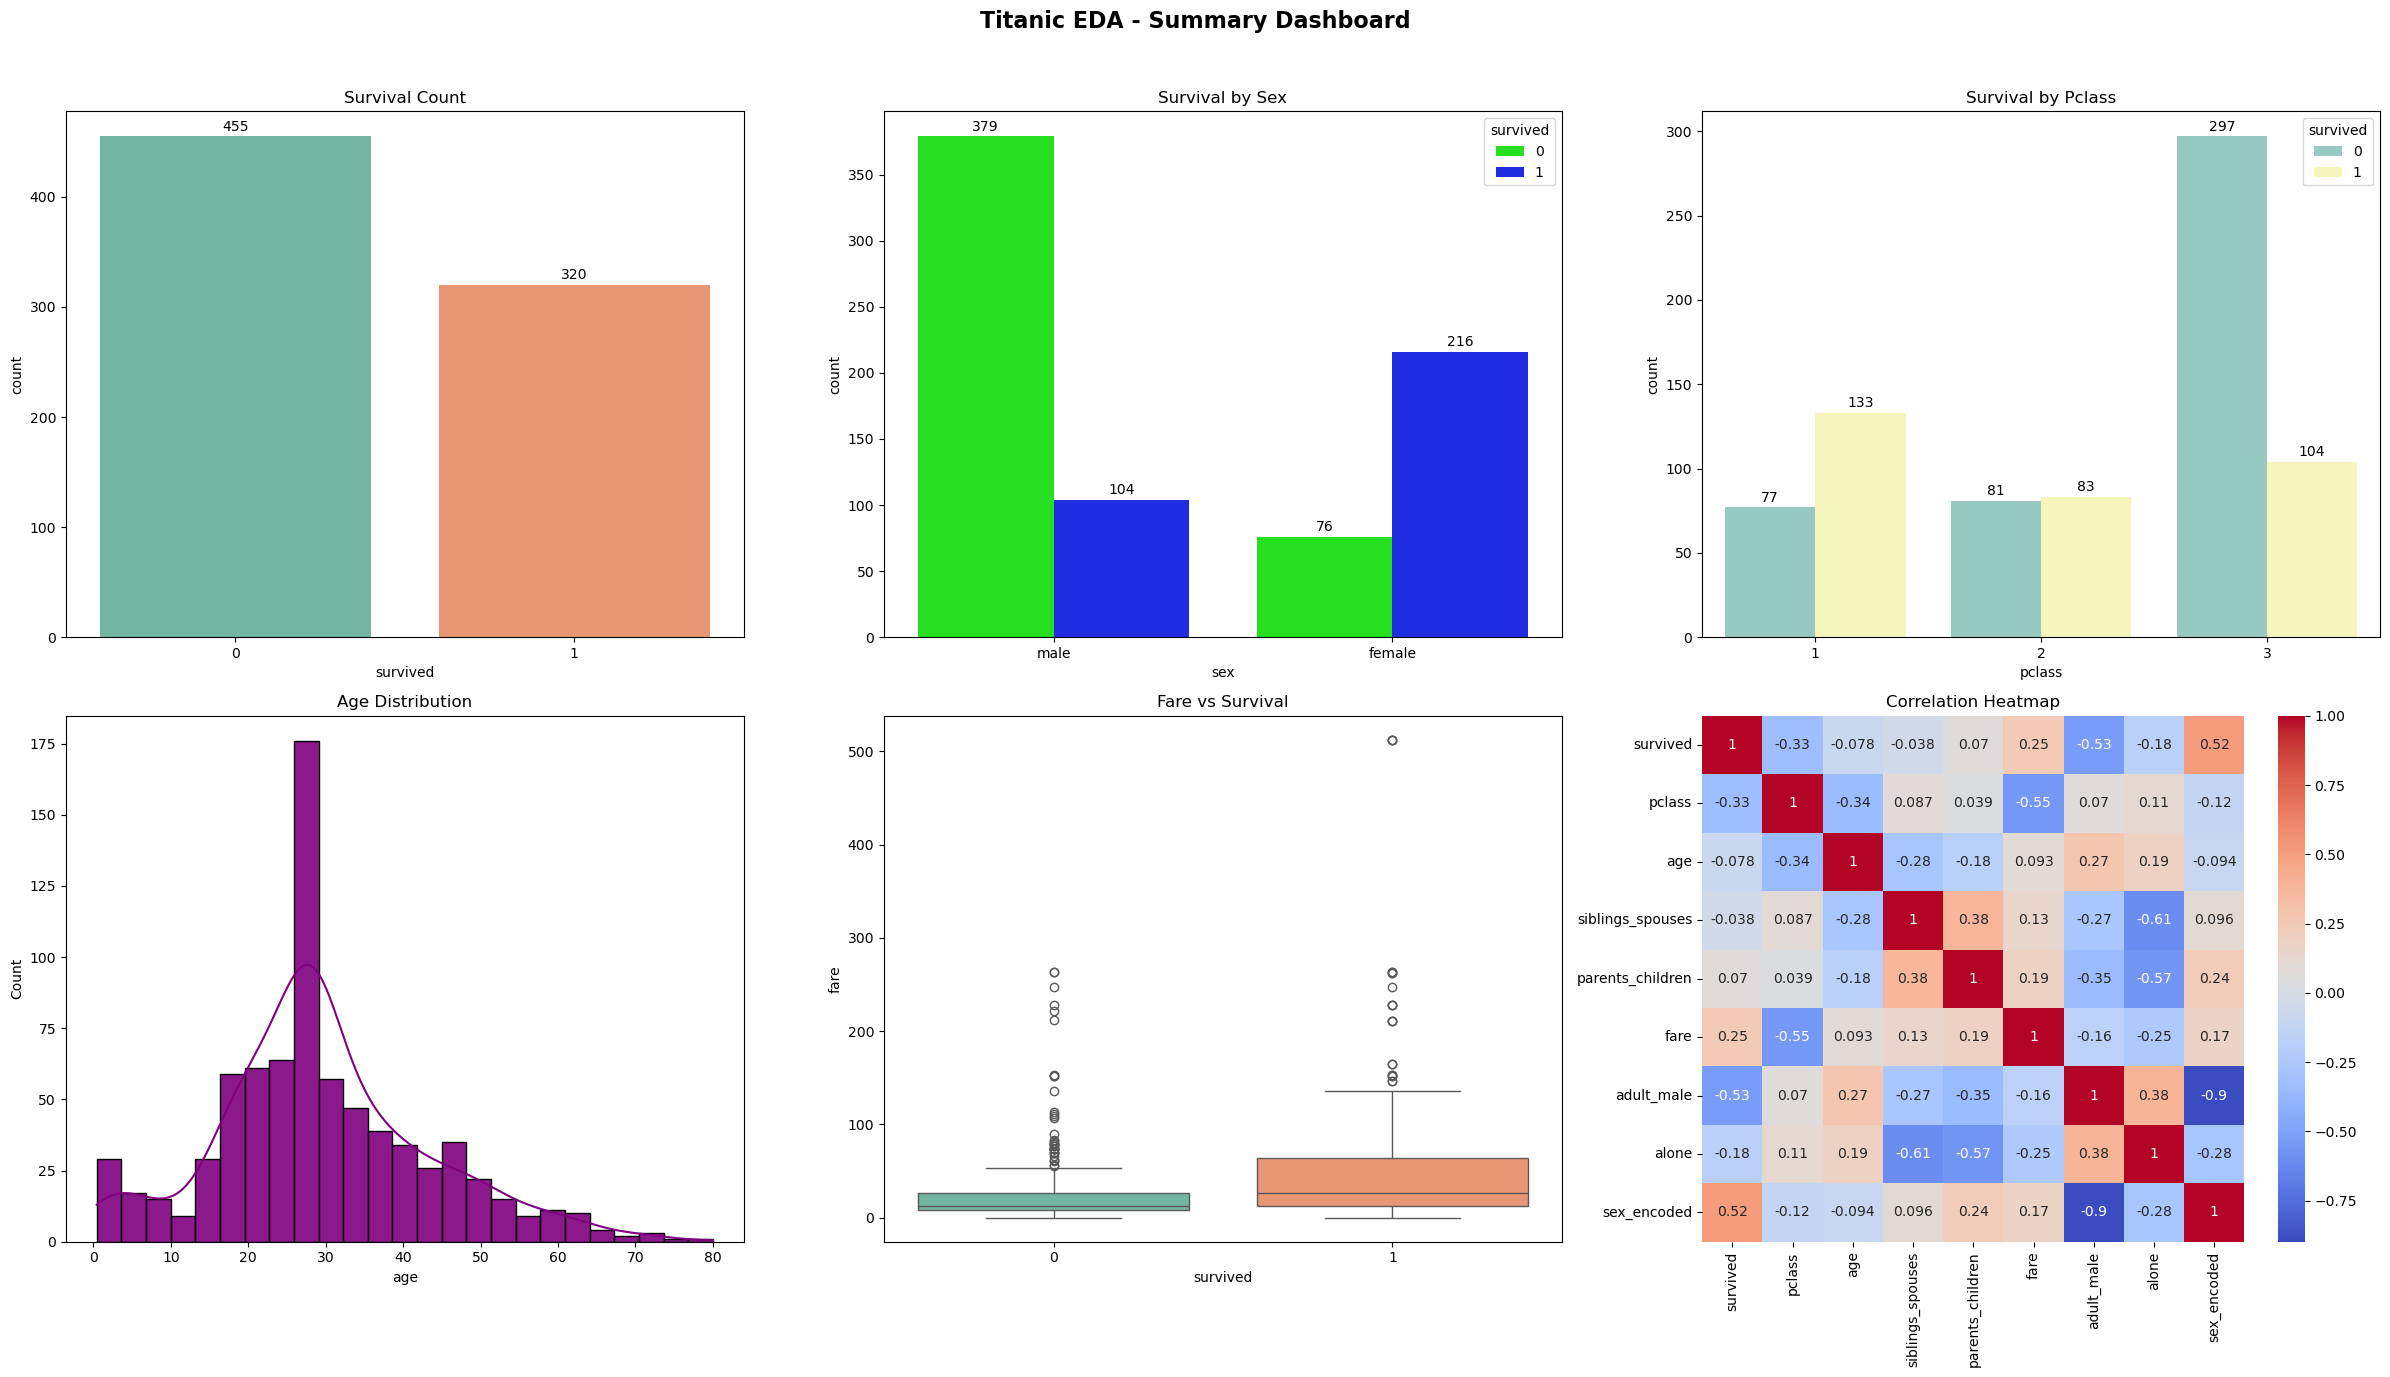

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle("Titanic EDA - Summary Dashboard", fontsize=16, fontweight='bold')

# 1. Survival count
sns.countplot(x='survived', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title("Survival Count")

# 2. Survival by Sex
sns.countplot(x='sex', hue='survived', data=df, palette='hsv', ax=axes[0,1])
axes[0,1].set_title("Survival by Sex")

# 3. Survival by Pclass
sns.countplot(x='pclass', hue='survived', data=df, palette='Set3', ax=axes[0,2])
axes[0,2].set_title("Survival by Pclass")

# 4. Age distribution
sns.histplot(data=df, x='age', bins=25, kde=True, ax=axes[1,0], color='purple', alpha=0.9)
axes[1,0].set_title("Age Distribution")

# 5. Fare boxplot
sns.boxplot(x='survived', y='fare', data=df, palette='Set2', ax=axes[1,1])
axes[1,1].set_title("Fare vs Survival")

# 6. Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title("Correlation Heatmap")

for ax in [axes[0,0], axes[0,1], axes[0,2]]:
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()